1. How many tennis players are included in the dataset?

In [12]:
import pandas as pd
#reading data of players that play either at home or away:
df_home = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_home_team")
df_away = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_away_team")


In [13]:
# df_away.head()
# df_home.head()
home_players = df_home['player_id']
away_players = df_away['player_id']
all_players = pd.concat([home_players, away_players])
unique_players = all_players.dropna().unique()
num_unique_players = len(unique_players)
print(f"number of players:{num_unique_players}")

number of players:2644


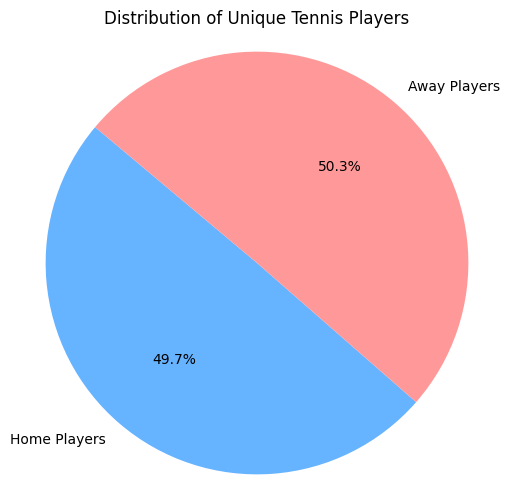

In [14]:
import matplotlib.pyplot as plt

unique_home_players = df_home['player_id'].dropna().nunique()
unique_away_players = df_away['player_id'].dropna().nunique()

labels = ['Home Players', 'Away Players']
sizes = [unique_home_players, unique_away_players]
colors = ['#66b3ff', '#ff9999']

# رسم نمودار پای چارت
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Distribution of Unique Tennis Players')
plt.axis('equal')  # برای دایره کامل
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q1.png",
    dpi=300,
    transparent=True,  #  حذف پس‌زمینه
    bbox_inches='tight',  # جلوگیری از برش تصویر
    pad_inches=0  # حذف حاشیه‌های اضافه
)
plt.show()

2. What is the average height of the players?

In [15]:
import pandas as pd
import numpy as np

df_home = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_home_team")
df_away = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_away_team")

players = pd.concat([df_home[["player_id", "height"]], df_away[["player_id", "height"]]])

players = players.drop_duplicates(subset="player_id")
players = players.dropna(subset=["height"])

average_height = np.mean(players["height"])

print("Average Player Height:", round(average_height, 2), "meters")
average_height


Average Player Height: 1.82 meters


np.float64(1.8213743356112377)

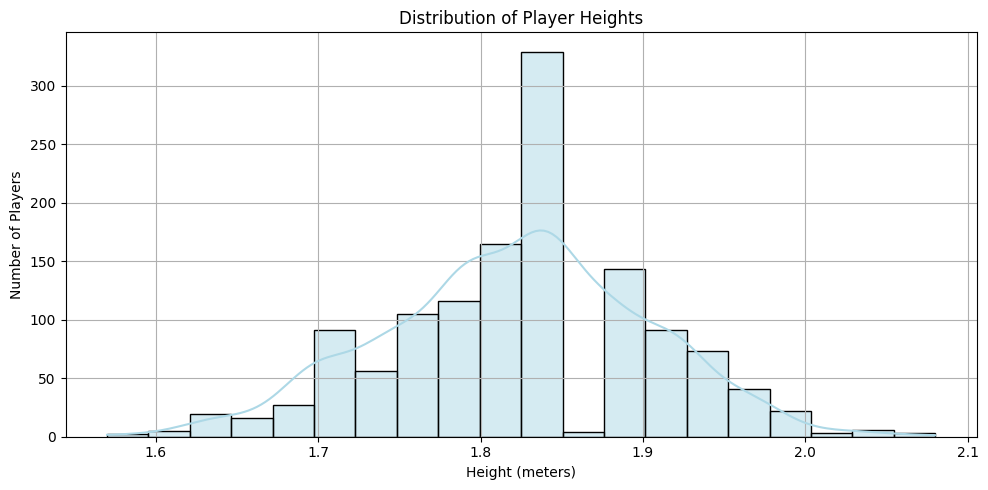

In [16]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(players["height"], bins=20, kde=True, color="lightblue")
plt.title("Distribution of Player Heights")
plt.xlabel("Height (meters)")
plt.ylabel("Number of Players")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q2.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()

3. Which player has the highest number of wins?

In [20]:
import pandas as pd

file = pd.ExcelFile("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx")

event = pd.read_excel(file, sheet_name="match_event")
home = pd.read_excel(file, sheet_name="match_home_team")[["match_id", "player_id", "full_name"]]
away = pd.read_excel(file, sheet_name="match_away_team")[["match_id", "player_id", "full_name"]]

# Merge اطلاعات بازیکن میزبان و مهمان
event = event.merge(home, on="match_id", how="left").rename(columns={"player_id": "home_id", "full_name": "home_name"})
event = event.merge(away, on="match_id", how="left").rename(columns={"player_id": "away_id", "full_name": "away_name"})

# ابتدا مقداردهی به ستون winner
event["winner"] = None
event.loc[event["winner_code"] == 1, "winner"] = event["home_name"]  # اگر winner_code 1 باشد، برنده میزبان است
event.loc[event["winner_code"] == 2, "winner"] = event["away_name"]  # اگر winner_code 2 باشد، برنده مهمان است

# حذف ردیف‌هایی که برنده ندارند
event = event.dropna(subset=["winner"])

# شمارش تعداد برد هر بازیکن
winner_counts = event["winner"].value_counts().reset_index()
winner_counts.columns = ["player_name", "wins"]

# نمایش بازیکنی با بیشترین برد
print("Top Player by Wins:")
print(winner_counts.head(1))


Top Player by Wins:
        player_name  wins
0  Chidekh, Clement   339


4. What is the longest match recorded in terms of duration?

In [3]:
import pandas as pd

# بارگذاری داده‌ها
excel_path="C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"

df_time = pd.read_excel(excel_path, sheet_name="match_time")

# پر کردن مقدارهای خالی با صفر
df_time_filled = df_time.fillna(0)

# محاسبه مجموع زمان ست‌ها برای هر مسابقه
df_time_filled['total_duration'] = (
    df_time_filled['period_1'] +
    df_time_filled['period_2'] +
    df_time_filled['period_3'] +
    df_time_filled['period_4'] +
    df_time_filled['period_5']
)

# پیدا کردن مسابقه با بیشترین زمان
longest_match = df_time_filled.loc[df_time_filled['total_duration'].idxmax()]

# نمایش اطلاعات
print("Match ID:", longest_match['match_id'])
print("Total Duration (minutes):", longest_match['total_duration']/60)

Match ID: 12063611.0
Total Duration (minutes): 5613.166666666667


In [26]:
# مرحله 1: پیدا کردن match_id طولانی‌ترین مسابقه
match_id = longest_match['match_id']

# مرحله 2: پیدا کردن اسم بازیکن میزبان
home_row = df_home[df_home['match_id'] == match_id]
home_name = home_row['full_name'].values[0]

# مرحله 3: پیدا کردن اسم بازیکن مهمان
away_row = df_away[df_away['match_id'] == match_id]
away_name = away_row['full_name'].values[0]

# مرحله 4: چاپ نتیجه
print("طولانی‌ترین مسابقه بین این دو بازیکن بوده:")
print("میزبان:", home_name)
print("مهمان:", away_name)

طولانی‌ترین مسابقه بین این دو بازیکن بوده:
میزبان: Shapatava, Sofia
مهمان: Branstine, Carson


5. How many sets are typically played in a tennis match?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
home_scores = pd.read_excel(excel_file, sheet_name='match_home_team_score')
away_scores = pd.read_excel(excel_file, sheet_name='match_away_team_score')

# محاسبه تعداد ست‌ها از هر دو دیدگاه
set_columns = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
home_scores['home_sets'] = (home_scores[set_columns] > 0).sum(axis=1)
away_scores['away_sets'] = (away_scores[set_columns] > 0).sum(axis=1)

# ادغام داده‌ها و حل ناسازگاری‌ها
merged = pd.merge(home_scores[['match_id', 'home_sets']], 
                 away_scores[['match_id', 'away_sets']], 
                 on='match_id')
merged['sets_played'] = merged[['home_sets', 'away_sets']].max(axis=1)

# ممکن است در داده‌ها ناسازگاری وجود داشته باشد (مثلاً یک طرف 3 ست و طرف دیگر 2 ست ثبت کرده باشد)

# استفاده از مکس یک روش محافظه‌کارانه است که مطمئن می‌شود همه ست‌های بازی شده را در نظر گرفته‌ایم.

# در تنیس معمولاً هر دو بازیکن باید تعداد ست‌های یکسانی بازی کرده باشند، اما اگر خطایی در داده‌ها وجود داشته باشد، این روش کمک می‌کند
mean_sets = merged['sets_played'].mean()
median_sets = merged['sets_played'].median()
mode_sets = merged['sets_played'].mode().values[0]
set_distribution = merged['sets_played'].value_counts().sort_index()




 Tennis Sets Played Analysis:
• Average number of sets: 2.1
• Median number of sets: 2.0
• Mode (most common) number of sets: 2

Set Count Distribution:
sets_played
0     4708
1     1020
2    50774
3    19649
Name: count, dtype: int64

Match Percentages:
sets_played
0     6.2%
1     1.3%
2    66.7%
3    25.8%
Name: count, dtype: object


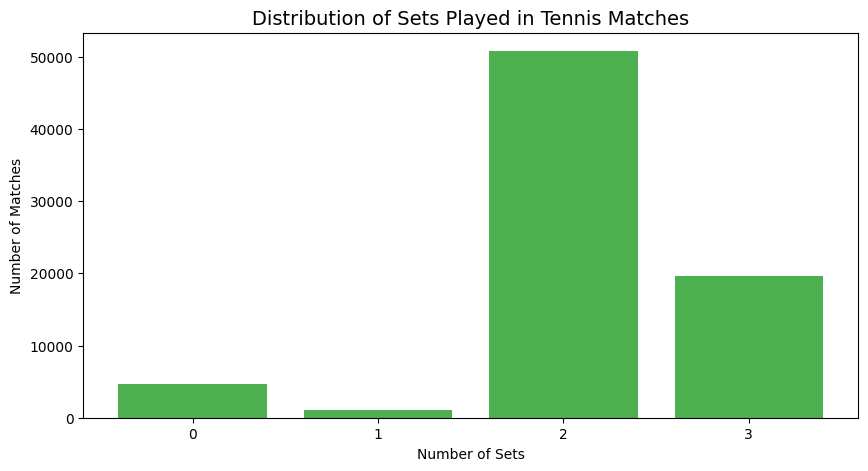

In [21]:
print("\n Tennis Sets Played Analysis:")
print(f"• Average number of sets: {mean_sets:.1f}")
print(f"• Median number of sets: {median_sets}")
print(f"• Mode (most common) number of sets: {mode_sets}")
print("\nSet Count Distribution:")
print(set_distribution)

# Display percentages
print("\nMatch Percentages:")
print((set_distribution / len(merged) * 100).round(1).astype(str) + "%")

# Create visualization
plt.figure(figsize=(10, 5))
bars = plt.bar(set_distribution.index, set_distribution.values, color='#4CAF50')
plt.title('Distribution of Sets Played in Tennis Matches', fontsize=14)
plt.xlabel('Number of Sets')
plt.ylabel('Number of Matches')
plt.xticks(set_distribution.index)
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q5.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()

6. Which country has produced the most successful tennis players?

In [41]:
# اگر بخواهیم موفقیت را برحسب بیشترین بازیکنان تنیس بسنجیم: 
import pandas as pd

# خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
home_players = pd.read_excel(excel_file, sheet_name='match_home_team')
away_players = pd.read_excel(excel_file, sheet_name='match_away_team')

# ترکیب اطلاعات بازیکنان خانگی و میهمان
all_players = pd.concat([
    home_players[['name', 'country']],
    away_players[['name', 'country']]
]).drop_duplicates()

# شمارش بازیکنان بر اساس کشور
country_stats = all_players['country'].value_counts().head(10)

print("10 کشور برتر با بیشترین تعداد بازیکنان تنیس:")
print(country_stats)



10 کشور برتر با بیشترین تعداد بازیکنان تنیس:
country
USA               224
Italy             206
France            202
Russia            137
Japan             123
Germany           121
Spain             100
Argentina          98
Australia          92
United Kingdom     86
Name: count, dtype: int64


In [17]:
import pandas as pd

# خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
home_players = pd.read_excel(excel_file, sheet_name='match_home_team')
away_players = pd.read_excel(excel_file, sheet_name='match_away_team')

# ترکیب داده‌ها و حذف بازیکنان تکراری
all_players = pd.concat([
    home_players[['player_id', 'name', 'country', 'current_rank', 'total_prize']],
    away_players[['player_id', 'name', 'country', 'current_rank', 'total_prize']]
]).drop_duplicates('player_id')



10 کشور برتر بر اساس مجموع جوایز کسب شده:
                player_count    avg_rank  total_prize
country                                              
USA                      225  681.680180  218863566.0
Spain                     98  721.814433  193407856.0
Serbia                    39  711.216216  180279177.0
France                   202  721.625000  160430678.0
Russia                   137  709.237037  143293718.0
Germany                  121  747.134454  104088628.0
Italy                    205  824.529703  100869168.0
United Kingdom            85  709.583333   97177751.0
Czech Republic            71  641.724638   73795177.0
Japan                    124  728.857143   62864285.0


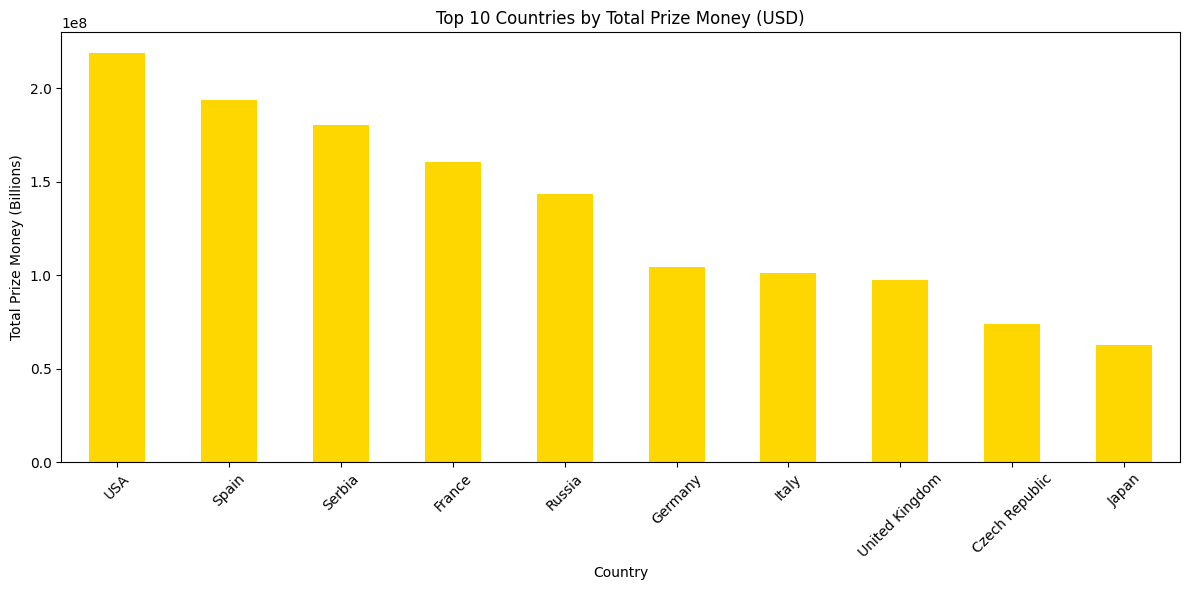

In [22]:
# اگر بخواهیم موفقیت را برحسب بیشترین جایزه یا رنک پایین تر  بسنجیم: 
# محاسبه آمار کشورها
country_stats = all_players.groupby('country').agg(
    player_count=('player_id', 'count'),  # تعداد بازیکنان منحصر به فرد
    avg_rank=('current_rank', 'mean'),    # میانگین رتبه
    total_prize=('total_prize', 'sum')    # مجموع جوایز
).sort_values('total_prize', ascending=False).head(10)

# نمایش نتایج
print("10 کشور برتر بر اساس مجموع جوایز کسب شده:")
print(country_stats[['player_count', 'avg_rank', 'total_prize']])

# نمایش نمودار
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
country_stats['total_prize'].plot(kind='bar', color='gold')
plt.title('Top 10 Countries by Total Prize Money (USD)')
plt.xlabel('Country')
plt.ylabel('Total Prize Money (Billions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q6.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()

7. What is the average number of aces per match?
Ace (سرویس مستقیم و بدون پاسخ)

In [23]:
import pandas as pd

# خواندن داده‌ها
csv_file = "C:\\Users\\pc\\Desktop\\project\\data\\statistics.csv"
period_info = pd.read_csv(csv_file)

# فیلتر کردن داده‌های Ace
aces_data = period_info[period_info['statistic_name'].str.contains('aces', case=False, na=False)]

# محاسبه مجموع Ace برای هر مسابقه
home_aces = aces_data.groupby('match_id')['home_value'].sum()
away_aces = aces_data.groupby('match_id')['away_value'].sum()
total_aces = home_aces + away_aces

# محاسبه میانگین
average_aces = total_aces.mean()

print(f"\nمیانگین تعداد Ace در هر مسابقه: {average_aces:.1f}")


میانگین تعداد Ace در هر مسابقه: 21.7


8. Is there a difference in the number of double faults based on gender?

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
home= pd.read_excel(excel_file, sheet_name='match_home_team')[['match_id', 'player_id', 'gender']]
away= pd.read_excel(excel_file, sheet_name='match_away_team')[['match_id', 'player_id', 'gender']]
statistics = pd.read_csv("C:\\Users\\pc\\Desktop\\project\\data\\statistics.csv")

# ۲. فیلتر فقط ردیف‌های double fault
Double_Fault=statistics[statistics['statistic_name'] == 'double_faults']

# ۳. وصل کردن جنسیت بازیکن‌ها به اطلاعات آماری
df_home = Double_Fault.merge(home[['match_id', 'gender']], on='match_id', how='left')
df_away = Double_Fault.merge(away[['match_id', 'gender']], on='match_id', how='left', suffixes=('_stat', '_away'))

# ۴. محاسبه مجموع double fault بر اساس جنسیت برای هر طرف
home_stats = df_home.groupby('gender')['home_value'].sum()
away_stats = df_away.groupby('gender')['away_value'].sum()

# ۵. جمع نهایی double faultها برای هر جنسیت
total_df = home_stats.add(away_stats, fill_value=0)
total_percentage = (total_df / total_df.sum()) * 100

print("\nتعداد کل Double Faults بر اساس جنسیت:")
print(total_df)
print("\nدرصد توزیع:")
print(total_percentage.round(1).astype(str) + "%")


تعداد کل Double Faults بر اساس جنسیت:
gender
F    253675
M    255545
dtype: int64

درصد توزیع:
gender
F    49.8%
M    50.2%
dtype: object


9. Which player has won the most tournaments in a single month?

In [25]:
import pandas as pd

# خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
event = pd.read_excel(excel_file, sheet_name="match_event")
home = pd.read_excel(excel_file, sheet_name="match_home_team")
away = pd.read_excel(excel_file, sheet_name="match_away_team")
tournaments = pd.read_excel(excel_file, sheet_name="match_tournament")

# فقط بازی‌هایی که برنده مشخص دارند
event = event[event['winner_code'].isin([1, 2])].copy()

# تبدیل تاریخ شروع به datetime و استخراج year-month
event['date'] = pd.to_datetime(event['start_datetime'], unit='s', errors='coerce')
event['year_month'] = event['date'].dt.to_period('M')

# اضافه کردن اطلاعات تورنمنت
event = event.merge(tournaments[['match_id', 'tournament_id']], on='match_id', how='left')

# پیدا کردن آخرین مسابقه هر تورنمنت بر اساس match_id (فرض بر اینکه بالاترین match_id = فینال)
final_matches = event.sort_values('match_id').groupby('tournament_id').tail(1)

# مشخص کردن برنده (home یا away)
winners_home = final_matches[final_matches['winner_code'] == 1].merge(
    home[['match_id', 'player_id', 'full_name']], on='match_id', how='left'
).rename(columns={'player_id': 'winner_id', 'full_name': 'winner_name'})

winners_away = final_matches[final_matches['winner_code'] == 2].merge(
    away[['match_id', 'player_id', 'full_name']], on='match_id', how='left'
).rename(columns={'player_id': 'winner_id', 'full_name': 'winner_name'})

# ترکیب
final_winners = pd.concat([winners_home, winners_away], ignore_index=True)

# حذف تورنمنت‌های تکراری
final_winners = final_winners[['tournament_id', 'year_month', 'winner_id', 'winner_name']].drop_duplicates()

# شمارش تعداد تورنمنت‌های برده شده در هر ماه
monthly_titles = final_winners.groupby(['winner_id', 'winner_name', 'year_month']).size().reset_index(name='win_count')

# پیدا کردن بیشترین برد در یک ماه
top = monthly_titles.sort_values(by='win_count', ascending=False).head(10)

print("🏆 بازیکنانی که بیشترین تورنمنت را در یک ماه برده‌اند:")
print(top)


🏆 بازیکنانی که بیشترین تورنمنت را در یک ماه برده‌اند:
     winner_id            winner_name year_month  win_count
210   202572.0          Gengel, Marek    2024-02          3
37     50901.0          Popko, Dmitry    2024-02          3
202   199379.0           Kopp, Sandro    2024-03          3
254   230049.0  Jianu, Filip Cristian    2024-03          3
379   372311.0           Nicod, Jakub    2024-03          3
363   341818.0           Faria, Jaime    2024-03          3
146   152766.0          Helgo, Malene    2024-03          3
328   300559.0   Glushkova, Denislava    2024-03          2
367   349351.0  Ciric Bagaric, Lucija    2024-02          2
107   107357.0          Grenier, Hugo    2024-02          2


In [26]:
import pandas as pd


# 1. خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
event = pd.read_excel(excel_file, sheet_name="match_event")
home = pd.read_excel(excel_file, sheet_name="match_home_team")
away = pd.read_excel(excel_file, sheet_name="match_away_team")


# 2. حذف مسابقاتی که winner_code خالی دارن
event = event[event['winner_code'].isin([1, 2])].copy()

# 3. ساختن ستون تاریخ (تبدیل به datetime و استخراج ماه-سال)
event['date'] = pd.to_datetime(event['start_datetime'], unit='s', errors='coerce')
event['year_month'] = event['date'].dt.to_period('M')  # مثل "2022-07"

# 4. اضافه کردن player_id و full_name بر اساس برنده
def get_winner(row):
    if row['winner_code'] == 1:
        player = home[home['match_id'] == row['match_id']]
    else:
        player = away[away['match_id'] == row['match_id']]
    if not player.empty:
        return pd.Series([player['player_id'].values[0], player['full_name'].values[0]])
    else:
        return pd.Series([None, None])

event[['winner_id', 'winner_name']] = event.apply(get_winner, axis=1)

# 5. گروه‌بندی بر اساس بازیکن و ماه
monthly_wins = event.groupby(['winner_id', 'winner_name', 'year_month']).size().reset_index(name='win_count')

# 6. پیدا کردن رکورد بیشترین برد در یک ماه
top = monthly_wins.sort_values(by='win_count', ascending=False).head()

print("بازیکنی که بیشترین مسابقه را در یک ماه برده:")
print(top)


بازیکنی که بیشترین مسابقه را در یک ماه برده:
      winner_id         winner_name year_month  win_count
559     69964.0    Estable, Julieta    2024-03         37
308     50901.0       Popko, Dmitry    2024-02         34
3208   341818.0        Faria, Jaime    2024-03         34
811    100093.0  Ferrari, Francesco    2024-03         31
1915   217447.0      Cekirge, Kuzey    2024-03         30


,winner_id,winner_name,year_month,win_count
559,69964.0,"Estable, Julieta",2024-03,37
308,50901.0,"Popko, Dmitry",2024-02,34
3208,341818.0,"Faria, Jaime",2024-03,34
811,100093.0,"Ferrari, Francesco",2024-03,31
1915,217447.0,"Cekirge, Kuzey",2024-03,30


10. Is there a correlation between a player's height and their ranking?

In [27]:
import pandas as pd

# 1. خواندن داده‌های بازیکن
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
home = pd.read_excel(excel_file, sheet_name="match_home_team")
away = pd.read_excel(excel_file, sheet_name="match_away_team")
# 2. ترکیب دو جدول
players = pd.concat([home, away])

# 3. حذف تکراری‌ها با استفاده از player_id
players = players.drop_duplicates(subset='player_id')

# 4. حذف داده‌های بدون قد یا رنک
players = players.dropna(subset=['height', 'current_rank'])

# 5. بررسی همبستگی (پیرسون)
correlation = players['height'].corr(players['current_rank'])

print("ضریب همبستگی بین قد و رنکینگ:", round(correlation, 3))


ضریب همبستگی بین قد و رنکینگ: 0.105


نشان میدهد بین قد و رنکینگ ارتباط معنا داری وجود ند ارد

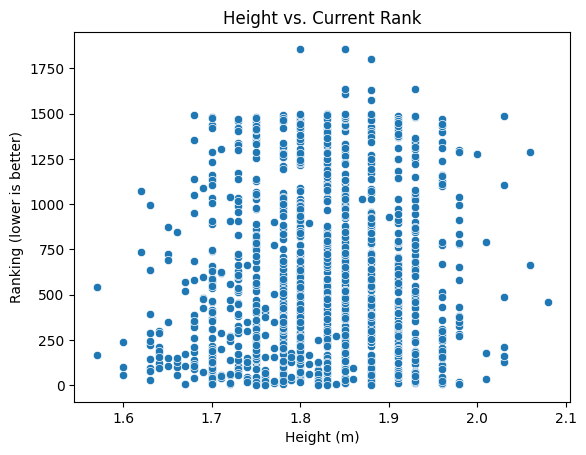

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=players, x='height', y='current_rank')
plt.title("Height vs. Current Rank")
plt.xlabel("Height (m)")
plt.ylabel("Ranking (lower is better)")
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q10.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()


11. What is the average duration of matches?

In [114]:
import pandas as pd

# 1. خواندن داده‌های match_time
df_time = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_time")

# 2. پر کردن مقدارهای خالی با صفر
df_time = df_time.fillna(0)

# 3. محاسبه مجموع زمان بازی‌ها برای هر مسابقه
set_columns = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
df_time['total_duration'] = df_time[set_columns].sum(axis=1)

# 4. میانگین کل مدت زمان
average_seconds = df_time['total_duration'].mean()

# 5. تبدیل ثانیه به ساعت:دقیقه:ثانیه
hours = int(average_seconds // 3600)
minutes = int((average_seconds % 3600) // 60)


print("میانگین مدت زمان مسابقه:")
print(f"{hours} hours and {minutes} minutes ")


میانگین مدت زمان مسابقه:
1 hours and 15 minutes 


12. What is the average number of games per set in men's matches compared to women's 
matches?
منظور از “تعداد گیم‌ها در هر ست” چیه؟
در تنیس، هر ست شامل چندین گیم هست. برای اینکه یک بازیکن ست رو ببره، معمولاً باید حداقل ۶ گیم ببره (با اختلاف ۲ گیم).

In [125]:
import pandas as pd

# 1. مسیر فایل اکسل
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"

# 2. خواندن شیت‌های مورد نیاز
home_score = pd.read_excel(excel_file, sheet_name="match_home_team_score")
away_score = pd.read_excel(excel_file, sheet_name="match_away_team_score")
home_info = pd.read_excel(excel_file, sheet_name="match_home_team")

# 3. مشخص کردن ست‌ها
set_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

# 4. ساختن دیتافریم برای مجموع گیم‌ها در هر ست (home + away)
total_games_df = home_score[['match_id'] + set_cols].copy()

# 5. جمع‌کردن گیم‌های میزبان و مهمان در هر ست
for col in set_cols:
    total_games_df[col] = home_score[col].fillna(0) + away_score[col].fillna(0)

# 6. محاسبه مجموع گیم‌ها و تعداد ست‌های بازی‌شده
total_games_df['total_games'] = total_games_df[set_cols].sum(axis=1)
total_games_df['sets_played'] = total_games_df[set_cols].apply(lambda row: (row > 0).sum(), axis=1)

# 7. اضافه کردن جنسیت (از تیم میزبان)
total_games_df = total_games_df.merge(home_info[['match_id', 'gender']], on='match_id', how='left')

# 8. حذف مسابقاتی که هیچ ستی بازی نشده
total_games_df = total_games_df[total_games_df['sets_played'] > 0]

# 9. محاسبه میانگین گیم‌ها در هر ست برای هر جنسیت
final_result = total_games_df.groupby('gender').apply(
    lambda df: df['total_games'].sum() / df['sets_played'].sum()
).round(2)

# 10. نمایش نتیجه
print(" میانگین گیم در هر ست برای هر جنسیت:")
print(final_result)

 میانگین گیم در هر ست برای هر جنسیت:
gender
F    9.16
M    9.51
dtype: float64


C:\Users\pc\AppData\Local\Temp\ipykernel_13052\2078684602.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_result = total_games_df.groupby('gender').apply(


13. What is the distribution of left-handed versus right-handed players?

In [29]:
import pandas as pd

# 1. خواندن داده‌های بازیکنان
home = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_home_team")
away = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_away_team")

# 2. ترکیب دو جدول و حذف بازیکنان تکراری بر اساس player_id
players = pd.concat([home, away])
players = players.drop_duplicates(subset='player_id')

# 3. محاسبه تعداد بازیکنان بر اساس 'plays'
handedness_count = players['plays'].value_counts(dropna=False)

# 4. محاسبه درصد
handedness_percent = (handedness_count / handedness_count.sum() * 100).round(2)

# 5. نمایش نتیجه
print(" توزیع بازیکنان چپ‌دست و راست‌دست:")
print(handedness_count)
print("\n به درصد:")
print(handedness_percent)


 توزیع بازیکنان چپ‌دست و راست‌دست:
plays
NaN             1498
right-handed    1013
left-handed      133
Name: count, dtype: int64

 به درصد:
plays
NaN             56.66
right-handed    38.31
left-handed      5.03
Name: count, dtype: float64


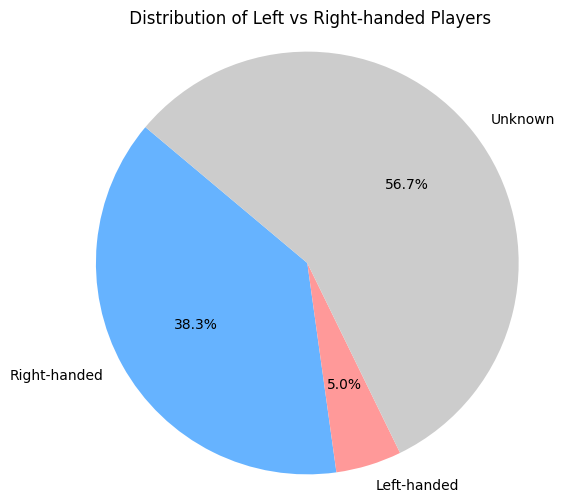

In [31]:
# نام دسته‌بندی‌ها
labels = ['Right-handed', 'Left-handed', 'Unknown']
sizes = [
    handedness_count.get('right-handed', 0),
    handedness_count.get('left-handed', 0),
    handedness_count.get(pd.NA, 0) + handedness_count.get(None, 0) + handedness_count.get(float('nan'), 0)
]
# رنگ‌ها برای زیبایی
colors = ['#66b3ff', '#ff9999', '#cccccc']

# رسم نمودار
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title(" Distribution of Left vs Right-handed Players")
plt.axis('equal')
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q13.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()

14. What is the most common type of surface used in tournaments?

In [33]:
import pandas as pd

# 1. خواندن شیت تورنمنت‌ها
df_tournament = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_tournament")

# 2. شمارش نوع زمین
surface_counts = df_tournament['ground_type'].value_counts(dropna=False)

# 3. درصدگیری
surface_percent = (surface_counts / surface_counts.sum() * 100).round(2)

# 4. نمایش
print(" شمارش انواع زمین:")
print(surface_counts)
print("\n درصد هر نوع زمین:")
print(surface_percent)


 شمارش انواع زمین:
ground_type
Hardcourt outdoor    16959
Red clay             11856
Hardcourt indoor      4741
NaN                    562
Red clay indoor        512
Grass                  509
Carpet indoor          276
Synthetic outdoor      226
Green clay              30
Name: count, dtype: int64

 درصد هر نوع زمین:
ground_type
Hardcourt outdoor    47.54
Red clay             33.24
Hardcourt indoor     13.29
NaN                   1.58
Red clay indoor       1.44
Grass                 1.43
Carpet indoor         0.77
Synthetic outdoor     0.63
Green clay            0.08
Name: count, dtype: float64


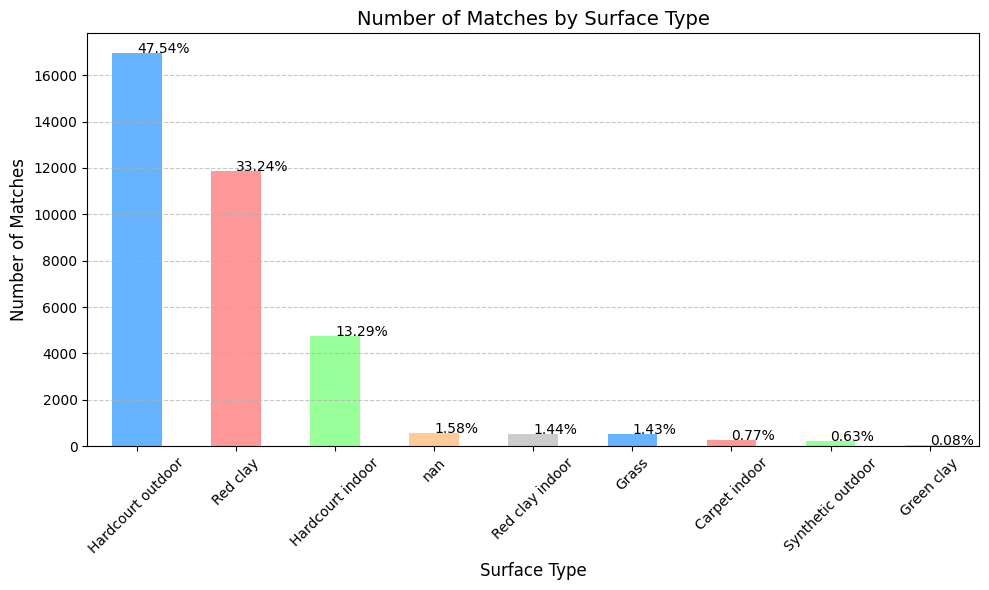

In [37]:
plt.figure(figsize=(10, 6))
bars = surface_counts.plot(kind='bar', color=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99', '#cccccc'])

# اضافه کردن درصدها روی هر میله
for i, (count, percent) in enumerate(zip(surface_counts, surface_percent)):
    plt.text(i, count + 5, f'{percent}%', fontsize=10)

plt.title("Number of Matches by Surface Type", fontsize=14)
plt.xlabel("Surface Type", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q14.png",
    dpi=300,
    transparent=True,  
    bbox_inches='tight',  
    pad_inches=0 
)
plt.show()

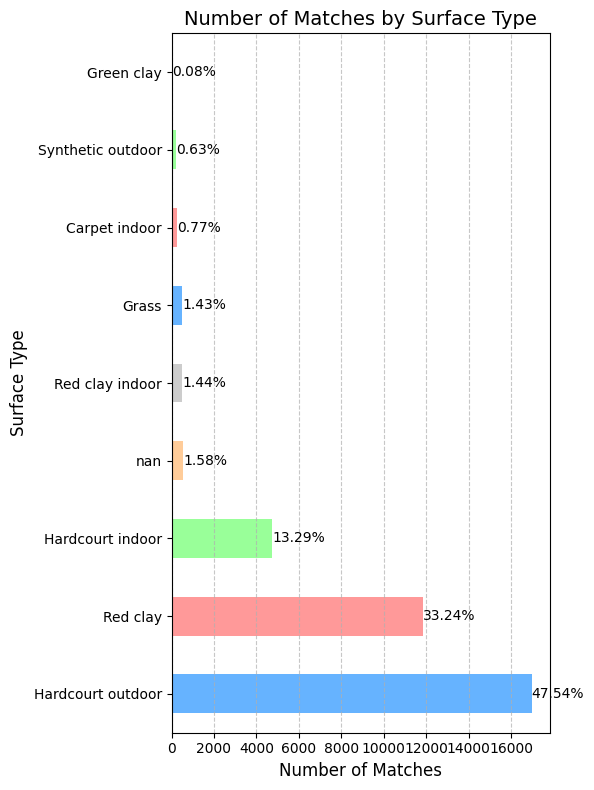

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,8))
bars = surface_counts.plot(kind='barh', color=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99', '#cccccc'])

# اضافه کردن درصدها روی میله‌ها
for i, (count, percent) in enumerate(zip(surface_counts, surface_percent)):
    plt.text(count + 5, i, f'{percent}%', va='center', fontsize=10)

plt.title("Number of Matches by Surface Type", fontsize=14)
plt.xlabel("Number of Matches", fontsize=12)
plt.ylabel("Surface Type", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(
    "C:/Users/pc/Desktop/project/output/Q14_horizontal.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()


15. How many distinct countries are represented in the dataset?

In [140]:
import pandas as pd

# 1. خواندن داده‌ها
home = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_home_team")
away = pd.read_excel("C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx", sheet_name="match_away_team")

# 2. گرفتن کشورها
home_countries = home['country']
away_countries = away['country']

# 3. ترکیب کشورها و حذف تکراری‌ها و NaN
all_countries = pd.concat([home_countries, away_countries]).dropna().unique()

# 4. نمایش تعداد کشورها
print(f" تعداد کشورهای منحصربه‌فرد در دیتاست: {len(all_countries)}")


 تعداد کشورهای منحصربه‌فرد در دیتاست: 101


16. Which player has the highest winning percentage against top 10 ranked opponents?


In [42]:
import pandas as pd

# 1. خواندن داده‌ها
excel_file = "C:\\Users\\pc\\Desktop\\project\\data\\match_tennis_data_combined.xlsx"
event = pd.read_excel(excel_file, sheet_name="match_event")
home = pd.read_excel(excel_file, sheet_name="match_home_team")
away = pd.read_excel(excel_file, sheet_name="match_away_team")

# 2. فقط مسابقاتی که برنده مشخص دارن
event = event[event['winner_code'].isin([1, 2])]

# 3. ادغام اطلاعات home و away برای اضافه کردن رنکینگ و player_id به event
event = event.merge(home[['match_id', 'player_id', 'full_name', 'current_rank']], on='match_id', how='left') \
             .rename(columns={'player_id': 'home_id', 'full_name': 'home_name', 'current_rank': 'home_rank'})

event = event.merge(away[['match_id', 'player_id', 'full_name', 'current_rank']], on='match_id', how='left') \
             .rename(columns={'player_id': 'away_id', 'full_name': 'away_name', 'current_rank': 'away_rank'})

# 4. پیدا کردن مسابقاتی که یکی از طرفین top 10 بوده
def check_top10(row):
    return row['home_rank'] <= 10 or row['away_rank'] <= 10

event = event.dropna(subset=['home_rank', 'away_rank'])
event = event[event.apply(check_top10, axis=1)]

# 5. برای هر مسابقه، مشخص کن چه کسی مقابل top10 بازی کرده و آیا برنده شده یا نه
results = []

for _, row in event.iterrows():
    if row['home_rank'] <= 10:
        opponent_id = row['away_id']
        opponent_name = row['away_name']
        is_win = row['winner_code'] == 2  # یعنی بازیکن away (opponent) برنده شده
    elif row['away_rank'] <= 10:
        opponent_id = row['home_id']
        opponent_name = row['home_name']
        is_win = row['winner_code'] == 1  # یعنی بازیکن home (opponent) برنده شده
    else:
        continue  # هر دو خارج از Top 10

    results.append((opponent_id, opponent_name, is_win))

# تبدیل به DataFrame
df_results = pd.DataFrame(results, columns=['player_id', 'player_name', 'won'])

# 6. محاسبه درصد برد
summary = df_results.groupby(['player_id', 'player_name']).agg(
    total_matches=('won', 'count'),
    wins=('won', 'sum')
).reset_index()

summary['win_percent'] = (summary['wins'] / summary['total_matches'] * 100).round(2)

# 7. فیلتر برای بازیکنانی که حداقل مثلاً 5 بازی مقابل top10 داشتن
summary = summary[summary['total_matches'] >= 5]

# 8. پیدا کردن بهترین بازیکن
top_player = summary.sort_values(by='win_percent', ascending=False).head(10)

print("بازیکنی با بیشترین درصد برد مقابل بازیکنان Top 10:")
print(top_player)


بازیکنی با بیشترین درصد برد مقابل بازیکنان Top 10:
     player_id        player_name  total_matches  wins  win_percent
69    127208.0   Altmaier, Daniel              8     8        100.0
24     47603.0   Monteiro, Thiago              8     8        100.0
129   372312.0      Mensik, Jakub              8     8        100.0
124   289233.0        Nardi, Luca              8     8        100.0
121   275923.0    Alcaraz, Carlos             24    24        100.0
116   262594.0   Avanesyan, Elina              8     8        100.0
111   256104.0    Volynets, Katie              8     8        100.0
98    206570.0     Sinner, Jannik              9     9        100.0
84    185388.0       Humbert, Ugo             24    24        100.0
79    163480.0  Bublik, Alexander             27    27        100.0


In [43]:
# 8. پیدا کردن بهترین بازیکن
top_player = summary.sort_values(by='win_percent', ascending=False).head(20)

print(" بازیکنی با بیشترین درصد برد مقابل بازیکنان:")
print(top_player)

 بازیکنی با بیشترین درصد برد مقابل بازیکنان:
     player_id           player_name  total_matches  wins  win_percent
69    127208.0      Altmaier, Daniel              8     8       100.00
24     47603.0      Monteiro, Thiago              8     8       100.00
129   372312.0         Mensik, Jakub              8     8       100.00
124   289233.0           Nardi, Luca              8     8       100.00
121   275923.0       Alcaraz, Carlos             24    24       100.00
116   262594.0      Avanesyan, Elina              8     8       100.00
111   256104.0       Volynets, Katie              8     8       100.00
98    206570.0        Sinner, Jannik              9     9       100.00
84    185388.0          Humbert, Ugo             24    24       100.00
79    163480.0     Bublik, Alexander             27    27       100.00
55     90664.0    Kalinina, Anhelina              8     8       100.00
51     87690.0      Thompson, Jordan              8     8       100.00
44     69208.0      Paolini, Jas

17. What is the average number of breaks of serve per match?
وقتی بازیکن سرویس‌زننده گیم را می‌بازد، به آن می‌گوییم "Break of Serve"
و یکی از مهم‌ترین شاخص‌های برتری تاکتیکی در تنیس محسوب می‌شه.

In [147]:
import pandas as pd

# 1. خواندن جدول PowerInfo
df_power = pd.read_csv("C:\\Users\\pc\\Desktop\\project\\data\\tennis_power.csv")

# 2. فقط ردیف‌هایی که break_occurred = True
df_breaks = df_power[df_power['break_occurred'] == True]

# 3. شمارش تعداد breakها در هر مسابقه
breaks_per_match = df_breaks.groupby('match_id').size()

# 4. محاسبه میانگین بریک در هر مسابقه
average_breaks = breaks_per_match.mean().round(0)

print(f" میانگین تعداد Break of Serve در هر مسابقه: {average_breaks}")


 میانگین تعداد Break of Serve در هر مسابقه: 14.0
